# Lag-response grid

This notebook makes Fig. S4: for a spread of (E, τ) configurations of one dyad, it
plots final CCM skill (ρ) as a function of the lag ℓ between TSI and temperature.
Each library-size convergence trajectory from the previous notebook collapses here
into one number: for a given (E, τ), the optimal lag is the positive ℓ (TSI leading
temperature) that maximizes convergent ρ. Only positive lags are considered, since
solar forcing should precede its imprint in temperature rather than the other way
around, following [@Ye:2015aa]. That one number per configuration is what
carries forward into every later multi-dyad comparison.

This notebook builds the conventional CCM lag grid from processed Paleobook outputs.
The real response line and the surrogate scatter come from `delta_rho_stats`, so it
doesn't need the original timeseries or the much larger `delta_rho_full` bootstrap
outputs.



In [7]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from cedarkit.viz.panels import LagPlot
from cedarkit.viz.grids import GridPlot
from cedarkit.utils.io.cloudjoblib import joblib_cloud_load
from cedarkit.core.project_config import load_config
from cedarkit.utils.cli.logging import setup_logging
from cedarkit.utils.plotting import save_figure

warnings.filterwarnings("ignore", category=FutureWarning)
notebook_name = "plot__DataGroup_lag"
os.environ["CEDAR_LOG_LEVEL"] = "INFO"
setup_logging(force=True)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Locate the processed dyad

This expects the copied `tmp/` directory to contain the object-grid joblib and
one `delta_rho_stats` parquet file for each plotted `(E, tau)` pair.


In [8]:
stem = Path(*(p := Path.cwd().resolve()).parts[: p.parts.index("notebooks")])

proj_name = "GISP2Alley00Tanom_Vieira11TSI"
dyad_dir = stem / "hol_temp_tsi_ccm" / proj_name
tmp_dir = dyad_dir / "tmp"
config = load_config(dyad_dir / "proj_config.yaml")

figures_dir = stem / "figures" / notebook_name
figures_dir.mkdir(parents=True, exist_ok=True)
print(f"Using processed outputs in: {tmp_dir}")


Using processed outputs in: /Users/jlanders/PycharmProjects/CCM_software/hol_temp_tsi_ccm_pb/hol_temp_tsi_ccm/GISP2Alley00Tanom_Vieira11TSI/tmp


## Load the grid

The stored object grid supplies each `(E, tau)` configuration and its precomputed
results.

In [9]:
grid_path = tmp_dir / f"{proj_name}_obj_grid__update.joblib"
if not grid_path.exists():
    grid_path = tmp_dir / f"{proj_name}_obj_grid.joblib"
object_grid = joblib_cloud_load(grid_path)


def upgrade_legacy_grid_cell(cell_obj):
    if cell_obj is not None and not hasattr(cell_obj, "_outputs"):
        legacy_output = cell_obj.__dict__.pop("output", None)
        cell_obj._outputs = [] if legacy_output is None else [legacy_output]
    return cell_obj

object_grid_filtered = {}
for _, cell_obj in object_grid.items():
    cell_obj = upgrade_legacy_grid_cell(cell_obj)
    if cell_obj is None or cell_obj.output is None:
        continue
    output = cell_obj.output
    output.resolve_paths(dyad_dir, prefer_local=False)
    output.set_relationships()
    E, tau = output.grp_config.E, output.grp_config.tau
    if 4 <= E <= 10 and 1 <= tau <= 8:
        object_grid_filtered[(E, tau)] = cell_obj

print(f"Loaded {len(object_grid_filtered)} grid cells.")


Loaded 56 grid cells.


## Plot the full lag grid

Mean real responses are drawn as lines, surrogate summaries as scatter, over the
full (E, τ) sweep. Full per-lag surrogate distributions are only computed for a
handful of representative configurations — testing showed the surrogate
distribution is lag-invariant, so the remaining panels just show the surrogate
spread at the optimal lag.

/Users/jlanders/PycharmProjects/CCM_software/cedar_util/cedarkit/viz/grids.py:250: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  axes = subfig.subplots(1, self.ncols, gridspec_kw=dict(wspace=wspace, hspace=hspace, width_ratios=self.width_ratios)) if self.ncols > 1 else [subfig.add_subplot(1, 1, 1)]


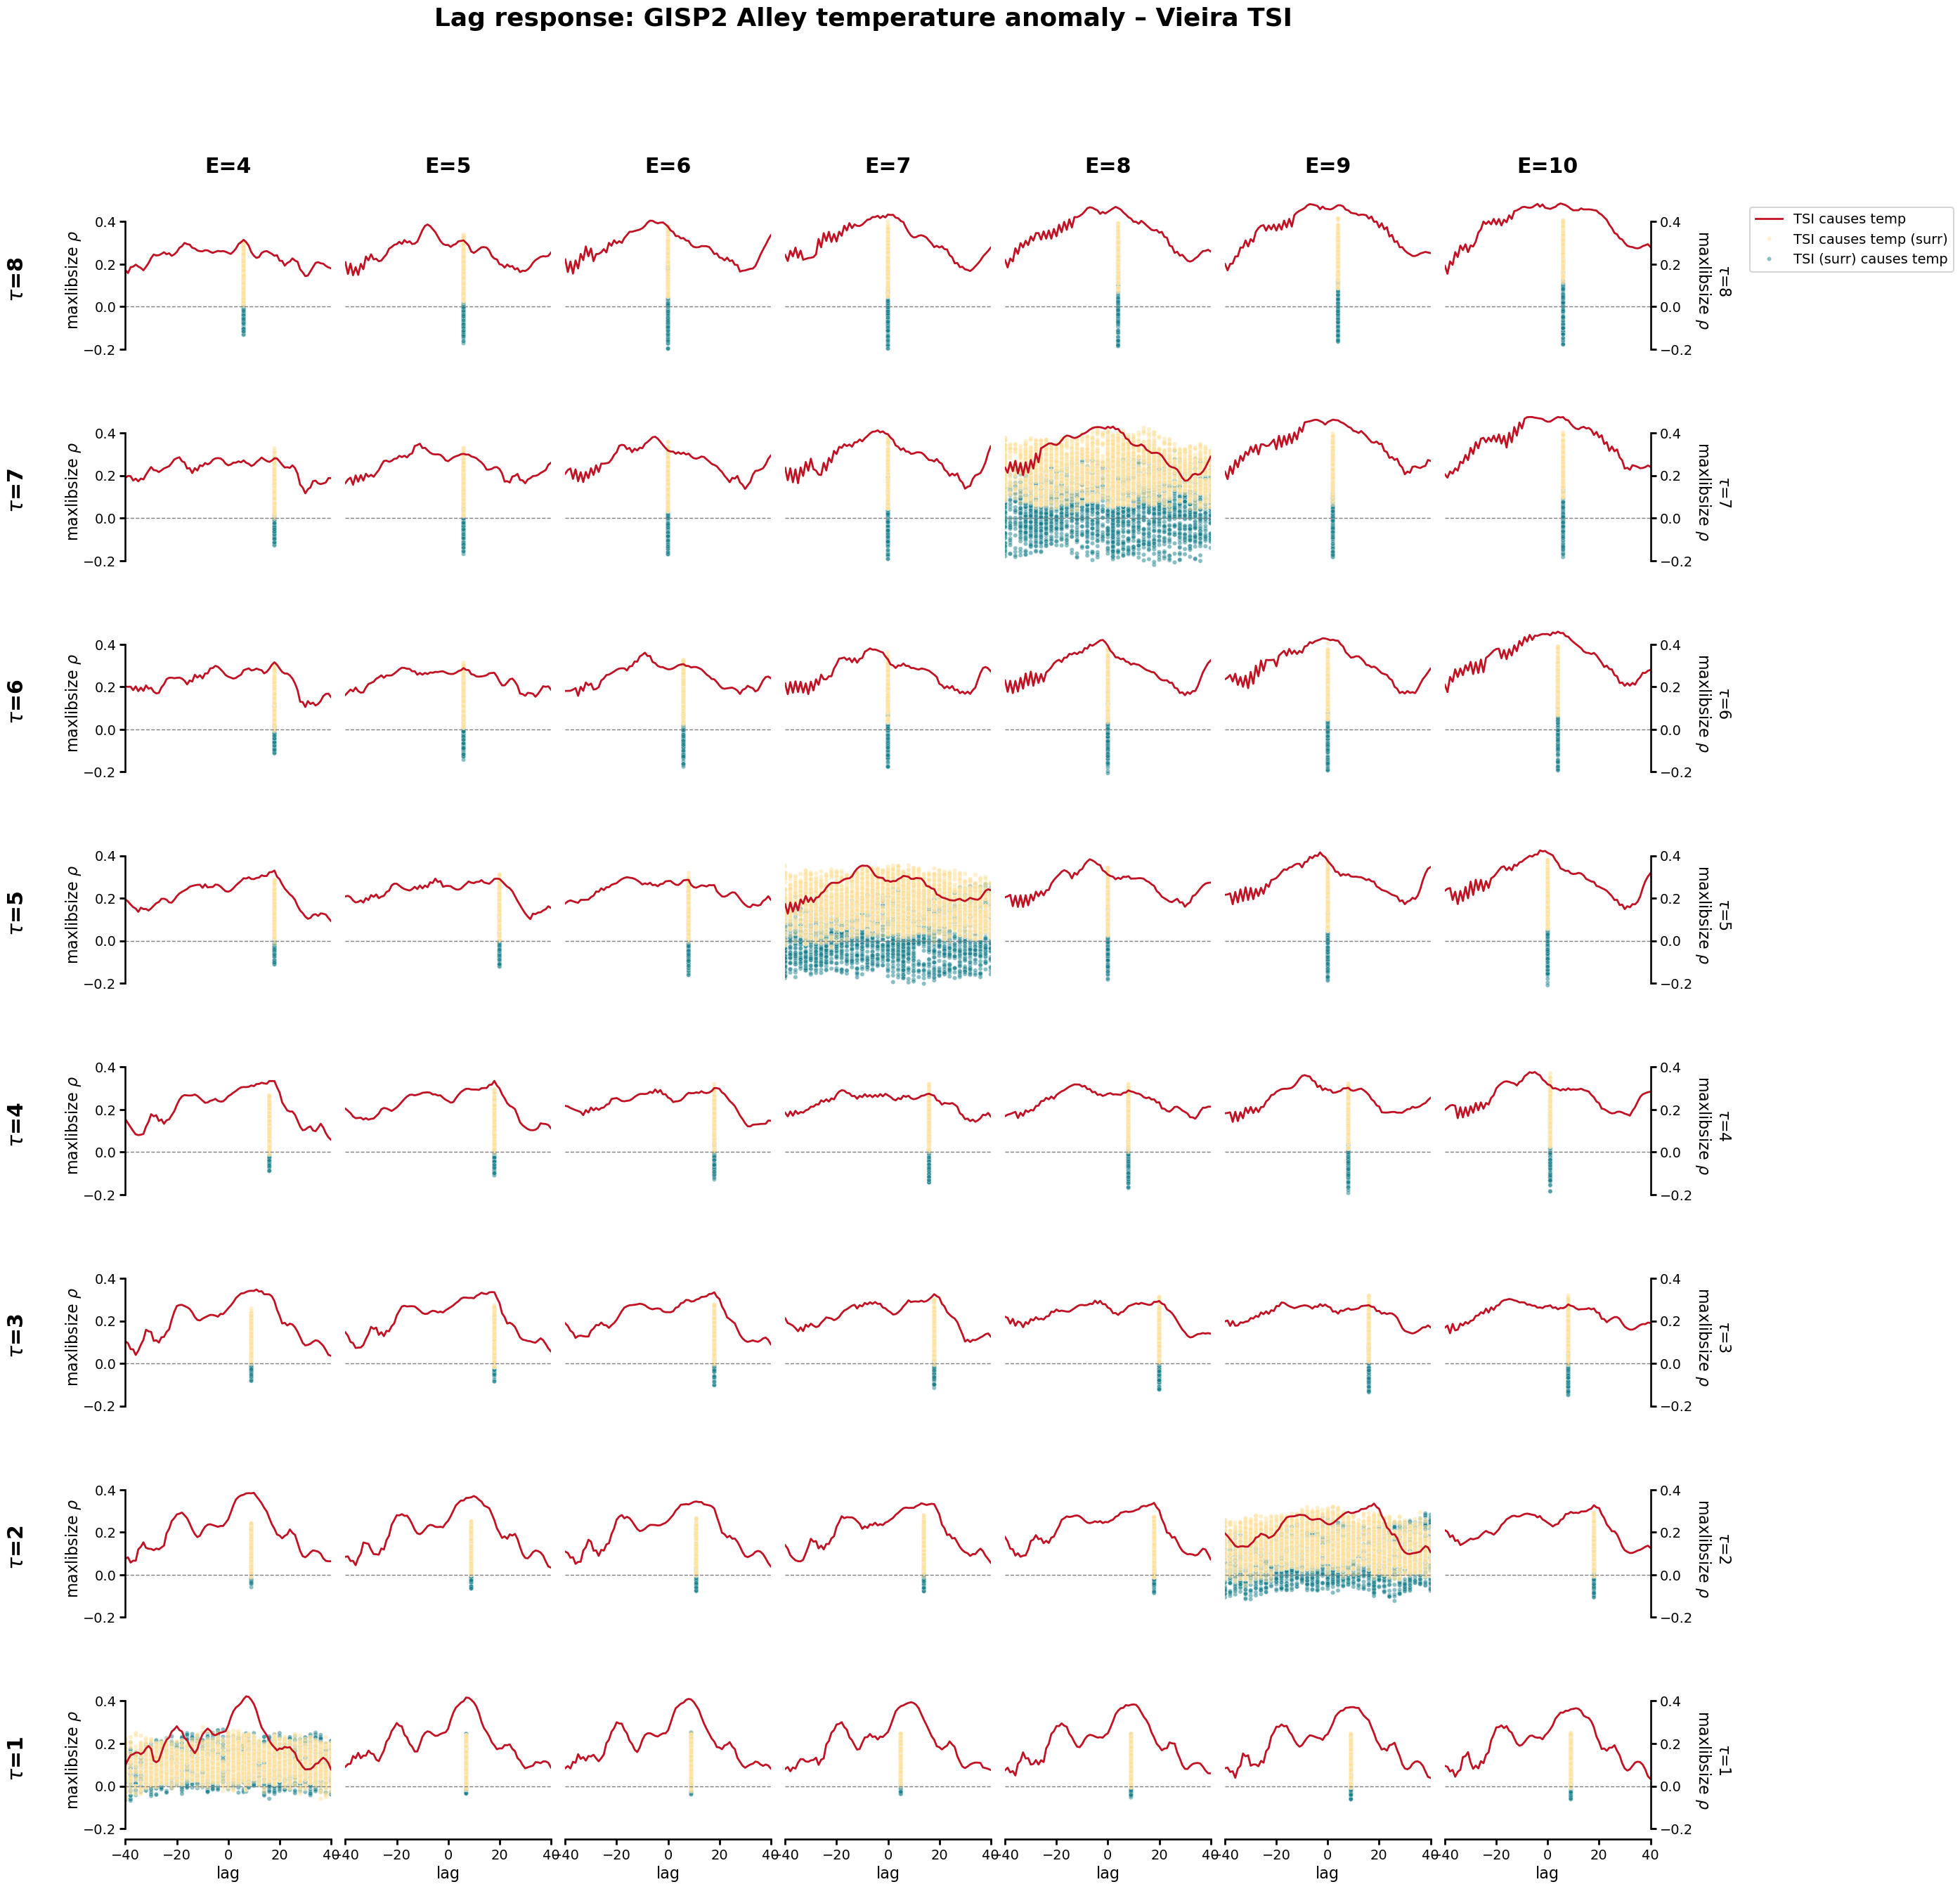

In [10]:
E_values = range(4, 11)
tau_values = range(1, 9)
available_E = [E for E in E_values if any(key[0] == E for key in object_grid_filtered)]
available_tau = [tau for tau in tau_values if any(key[1] == tau for key in object_grid_filtered)]
row_var, col_var = 'tau', 'E'
rows, cols = len(available_tau), len(available_E)
gridplot = GridPlot(rows, cols)
gridplot.title = "Lag response: GISP2 Alley temperature anomaly – Vieira TSI"
gridplot.xlims = [-40, 40]
gridplot.make_grid(figsize=(4 * cols, 3 * rows), hspace=.02, context="talk")

for row, row_var_val in enumerate(reversed(available_tau)):
    row_labels = [f"{row_var}={row_var_val}"]
    for col, col_var_val in enumerate(available_E):
        col_labels = [f"{col_var}={col_var_val}"]
        ax = gridplot.get_ax(row, col)

        E= row_var_val if row_var=='E' else col_var_val
        tau = row_var_val if row_var=='tau' else col_var_val
        cell_obj = object_grid_filtered.get((E, tau))
        if cell_obj is None:
            gridplot.set_ax(row, col, ax, entry_type=None)
            continue
        try:
            lag_plot = LagPlot(ax=ax, palette=config.pal.to_dict(), y_var="maxlibsize_rho")
            lag_plot.make_classic_lag_plot(
                cell_obj.output, stats_only=True, scatter=True, boxplot=False, relation_scope=["r1"]
            )
            lag_plot.annotations += cell_obj.annotations
            lag_plot.tidy_plot(legend=False)
            lag_plot.ax.set_ylabel('\n'.join(row_labels+lag_plot.ax.get_ylabel().split('\n')))
            lag_plot.ax.set_title('\n'.join(col_labels + [lag_plot.ax.get_title()]))
            gridplot.ylims += [lag_plot.min_y, lag_plot.max_y]
            gridplot.add_handles_labels(lag_plot.scatter_handles, lag_plot.scatter_labels, kind="scatter")
            gridplot.add_handles_labels(lag_plot.line_handles, lag_plot.line_labels, kind="line")
            gridplot.set_ax(row, col, lag_plot.ax, entry_type="plot")
        except Exception as error:
            print(f"Could not plot E={E}, tau={tau}: {error}")
            gridplot.set_ax(row, col, ax, entry_type=None)

gridplot.ylims = [-0.1, 0.5]
gridplot.remove_empty()
gridplot.tidy_rows(add_hline=0, ylim_by="central", title_pad=-5, num_xticks=5, num_yticks=5,
                   supylabel_offset=.07, rlabel_pad=40, titley=1.1)

gridplot.add_legend(bbox_to_anchor=(1.45, 1))
# save_figure(gridplot.fig, figures_dir, stem=f"lag_grid__{proj_name}", dry_run=True)


### Interpretation
Across most (E, τ) panels, the real "TSI causes temp" relationship (red) traces a similar shape: skill rises to a peak at a positive lag (TSI leading temperature), then falls off. That peak has to clear both surrogate categories ("TSI (surr) causes temp" cloud (green) and "TSI causes temp (surr)" cloud (light yellow)) for a configuration to count as evidence of a causal link. The peak is narrow and located at approximately 8 for shorter length snippets but broadens and starts to center around 0 for embedding configurations that yield long snippets.